In [62]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib

# === Load and filter ===
df = pd.read_csv("data/df_chembl.csv", low_memory=False)
df = df.rename(columns={
    "Canonical SMILES": "smiles",
    "pChEMBL": "pchembl",
    "Target ChEMBL ID": "target",
    "Preferred name": "name",
    "Molecule ChEMBL ID": "mol_id"
})

df = df[df["target"] == "CHEMBL2039"].dropna(subset=["smiles", "pchembl"])
df = df.sort_values("pchembl", ascending=False).drop_duplicates("mol_id")
df["label"] = df["name"].fillna(df["mol_id"])

# Sample randomly (e.g. 16 molecules)
sampled_df = df.sample(n=min(16, len(df)), random_state=42).copy()
sampled_df["mol"] = sampled_df["smiles"].apply(Chem.MolFromSmiles)
sampled_df["pchembl"] = pd.to_numeric(sampled_df["pchembl"], errors="coerce")

# === Generate RDKit grid image as PNG and get PIL image ===
legends = [f"{label}\npChEMBL: {p:.2f}" for label, p in zip(sampled_df["label"], sampled_df["pchembl"])]
img_pil = Draw.MolsToGridImage(
    sampled_df["mol"].tolist(),
    molsPerRow=4,
    subImgSize=(250, 250),
    legends=legends,
    useSVG=False,
    returnPNG=False  # Directly return PIL Image
)

# === Normalize pChEMBL values for color mapping ===
norm = plt.Normalize(vmin=sampled_df["pchembl"].min(), vmax=sampled_df["pchembl"].max())

# === Get colormap (e.g., coolwarm) ===
cmap = matplotlib.colormaps['coolwarm']  # Correct method for retrieving colormap
colors = [cmap(norm(p)) for p in sampled_df["pchembl"]]  # Get colors based on pChEMBL values

# === Overlay color boxes based on pChEMBL values ===
draw = ImageDraw.Draw(img_pil)  # Now we can draw on it
cell_w, cell_h = 250, 250
cols = 4

for i, pval in enumerate(sampled_df["pchembl"]):
    row = i // cols
    col = i % cols
    x0, y0 = col * cell_w, row * cell_h
    x1, y1 = x0 + cell_w, y0 + cell_h
    
    # Convert normalized color to RGB (from the colormap)
    color = tuple(int(c * 255) for c in colors[i][:3])  # Convert to RGB
    draw.rectangle([x0, y0, x1, y1], outline="black", fill=color)

# === Show and save ===
img_pil.show()
img_pil.save("highlighted_grid_heatmap.png")


In [89]:
import pandas as pd

# Load ChEMBL target data (for protein targets)
chembl_target_path = "data/ChEMBL35Targets.csv"  # Adjust the path to your target CSV
chembl_target_df = pd.read_csv(chembl_target_path, sep=";")

# Filter for human targets
human_targets = chembl_target_df[chembl_target_df["Organism"] == "Homo sapiens"].copy()

# Load the molecule data
df = pd.read_csv("../../../Downloads/DOWNLOAD-zH5JeGNaaRMW_BhMB9SUmaSpQmBJVQ6gSO4udWEV5Rg_eq_.csv", delimiter=";")  # Adjust path to your CSV file

# Select columns of interest from the molecule data, including Smiles
columns_of_interest = ['Molecule ChEMBL ID', 'Molecule Name', 'pChEMBL Value', 'Target ChEMBL ID', 'Smiles']
filtered_df = df[columns_of_interest]

# Drop rows where pChEMBL Value is NaN
filtered_df_clean = filtered_df.dropna(subset=['pChEMBL Value'])

# Merge the filtered molecule dataframe with the human target dataframe on 'Target ChEMBL ID'
merged_df = pd.merge(filtered_df_clean, human_targets[['ChEMBL ID', 'Name']], left_on='Target ChEMBL ID', right_on='ChEMBL ID', how='left')

# Select the relevant columns for output and include 'Smiles'
merged_df = merged_df[['Molecule ChEMBL ID', 'Molecule Name', 'pChEMBL Value', 'Target ChEMBL ID', 'Name', 'Smiles']]

# Rename columns for clarity
merged_df = merged_df.rename(columns={'Name': 'Target Name'})

# Display the merged dataframe with Molecule names, pChEMBL values, Target Names, and SMILES
print(merged_df)

# Optionally save the merged dataframe
merged_df.to_csv("cleaned_molecules_with_target_names_and_smiles.csv", index=False)



     Molecule ChEMBL ID Molecule Name  pChEMBL Value Target ChEMBL ID  \
0         CHEMBL1276308  MIFEPRISTONE           4.75    CHEMBL1293235   
1          CHEMBL116438      CURCUMIN           4.60       CHEMBL4159   
2          CHEMBL157101  KETOCONAZOLE           5.72        CHEMBL240   
3              CHEMBL54   HALOPERIDOL           8.39        CHEMBL217   
4             CHEMBL118     CELECOXIB           7.68        CHEMBL205   
...                 ...           ...            ...              ...   
9126           CHEMBL98    VORINOSTAT           6.70       CHEMBL5103   
9127           CHEMBL98    VORINOSTAT           7.13       CHEMBL1829   
9128           CHEMBL98    VORINOSTAT           7.37        CHEMBL325   
9129           CHEMBL98    VORINOSTAT           6.84       CHEMBL1829   
9130           CHEMBL98    VORINOSTAT           6.99        CHEMBL325   

                                            Target Name  \
0                                          Prelamin-A/C   
1    

In [92]:
import pandas as pd

# Load ChEMBL target data (for protein targets)
chembl_target_path = "data/ChEMBL35Targets.csv"  # Adjust the path to your target CSV
chembl_target_df = pd.read_csv(chembl_target_path, sep=";")

# Filter for human targets
human_targets = chembl_target_df[chembl_target_df["Organism"] == "Homo sapiens"].copy()

# Load the molecule data
df = pd.read_csv("../../../Downloads/DOWNLOAD-zH5JeGNaaRMW_BhMB9SUmaSpQmBJVQ6gSO4udWEV5Rg_eq_.csv", delimiter=";")  # Adjust path to your CSV file

# Select columns of interest from the molecule data
columns_of_interest = ['Molecule ChEMBL ID', 'Molecule Name', 'pChEMBL Value', 'Target ChEMBL ID', 'Smiles']
filtered_df = df[columns_of_interest]

# Drop rows where pChEMBL Value is NaN
filtered_df_clean = filtered_df.dropna(subset=['pChEMBL Value'])

# Merge the filtered molecule dataframe with the human target dataframe on 'Target ChEMBL ID'
merged_df = pd.merge(filtered_df_clean, human_targets[['ChEMBL ID', 'Name']], left_on='Target ChEMBL ID', right_on='ChEMBL ID', how='left')

# Select the relevant columns for output and rename for clarity
merged_df = merged_df[['Molecule ChEMBL ID', 'Molecule Name', 'pChEMBL Value', 'Target ChEMBL ID', 'Name', 'Smiles']]
merged_df = merged_df.rename(columns={'Name': 'Target Name'})

# Ensure only the highest pChEMBL value is kept for duplicate Molecule ChEMBL IDs
merged_df = merged_df.loc[merged_df.groupby('Molecule ChEMBL ID')['pChEMBL Value'].idxmax()]

# Sample a few random rows to display (e.g., 10 random rows)
sampled_df = merged_df.sample(n=10, random_state=42)

# Display the top rows of the dataframe and random samples
print("Top rows based on highest pChEMBL values and random selection:")
print(merged_df.head())  # Show the top of the dataframe with unique pChEMBL values
print("\nRandomly selected molecules:")
print(sampled_df)  # Randomly selected rows

# Optionally, save the cleaned and processed data
merged_df.to_csv("cleaned_molecules_with_target_names_and_smiles.csv", index=False)



Top rows based on highest pChEMBL values and random selection:
     Molecule ChEMBL ID Molecule Name  pChEMBL Value Target ChEMBL ID  \
4089         CHEMBL1017   TELMISARTAN           9.48       CHEMBL4607   
2939         CHEMBL1023    BEXAROTENE           8.57       CHEMBL2061   
6422          CHEMBL103  PROGESTERONE          10.00        CHEMBL208   
1151        CHEMBL10316      IDAZOXAN           8.15       CHEMBL1867   
7012          CHEMBL106   FLUCONAZOLE           6.30    CHEMBL1293235   

                                Target Name  \
4089  Angiotensin II type 2 (AT-2) receptor   
2939              Retinoid X receptor alpha   
6422                  Progesterone receptor   
1151           Alpha-2a adrenergic receptor   
7012                           Prelamin-A/C   

                                                 Smiles  
4089  CCCc1nc2c(C)cc(-c3nc4ccccc4n3C)cc2n1Cc1ccc(-c2...  
2939   C=C(c1ccc(C(=O)O)cc1)c1cc2c(cc1C)C(C)(C)CCC2(C)C  
6422  CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(

In [97]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from PIL import Image

# Ensure the 'Smiles' column is properly parsed and convert to RDKit molecule objects
sampled_df["mol"] = sampled_df["Smiles"].apply(Chem.MolFromSmiles)

# Create legends for the molecules: name, pChEMBL value, and target name with a larger font size
legends = [f"{row['Molecule Name']}\npChEMBL: {row['pChEMBL Value']}\nTarget: {row['Target Name']}" 
           for _, row in sampled_df.iterrows()]

# Generate RDKit grid image with the required legends, larger font size, and increased resolution
img = Draw.MolsToGridImage(
    sampled_df["mol"].tolist(),
    molsPerRow=4,  # Number of molecules per row
    subImgSize=(350, 350),  # Increased image size for each molecule
    legends=legends,  # Add legends with molecule details
    useSVG=False,  # Set to False to generate PNG
    returnPNG=False,  # Return a PIL Image instead of PNG
    legendFontSize=14  # Increase font size for legends
)

# Display the grid
img.show()

# Save the image with a higher resolution (DPI)
img.save("molecule_grid_with_labels_high_res.png", "PNG", dpi=(300, 300))



ArgumentError: Python argument types in
    MolDraw2D.DrawMolecules(MolDraw2DCairo, list)
did not match C++ signature:
    DrawMolecules(RDKit::MolDraw2D {lvalue} self, boost::python::api::object mols, boost::python::api::object highlightAtoms=None, boost::python::api::object highlightBonds=None, boost::python::api::object highlightAtomColors=None, boost::python::api::object highlightBondColors=None, boost::python::api::object highlightAtomRadii=None, boost::python::api::object confIds=None, boost::python::api::object legends=None)

In [95]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import matplotlib

# Ensure the 'Smiles' column is properly parsed and convert to RDKit molecule objects
sampled_df["mol"] = sampled_df["Smiles"].apply(Chem.MolFromSmiles)

# Create legends for the molecules: name, pChEMBL value, and target name
legends = [f"{row['Molecule Name']}\npChEMBL: {row['pChEMBL Value']}\nTarget: {row['Target Name']}" 
           for _, row in sampled_df.iterrows()]

# === Generate RDKit grid image as PNG and get PIL image ===
img = Draw.MolsToGridImage(
    sampled_df["mol"].tolist(),
    molsPerRow=4,  # Number of molecules per row
    subImgSize=(250, 250),  # Image size for each molecule
    legends=legends,  # Add legends with molecule details
    useSVG=False,  # Set to False to generate PNG
    returnPNG=False  # Return a PIL Image instead of PNG
)

# === Normalize pChEMBL values for color mapping ===
norm = plt.Normalize(vmin=sampled_df["pChEMBL Value"].min(), vmax=sampled_df["pChEMBL Value"].max())

# === Get colormap (e.g., coolwarm) ===
cmap = matplotlib.colormaps['coolwarm']  # Correct method for retrieving colormap
colors = [cmap(norm(p)) for p in sampled_df["pChEMBL Value"]]  # Get colors based on pChEMBL values

# === Overlay color boxes based on pChEMBL values ===
draw = ImageDraw.Draw(img)  # Now we can draw on it
cell_w, cell_h = 250, 250
cols = 4

for i, pval in enumerate(sampled_df["pChEMBL Value"]):
    row = i // cols
    col = i % cols
    x0, y0 = col * cell_w, row * cell_h
    x1, y1 = x0 + cell_w, y0 + cell_h
    
    # Convert normalized color to RGB (from the colormap)
    color = tuple(int(c * 255) for c in colors[i][:3])  # Convert to RGB
    draw.rectangle([x0, y0, x1, y1], outline="black", fill=color)

# === Show and save the image ===
img.show()
img.save("molecule_grid_with_colored_borders.png", "PNG")


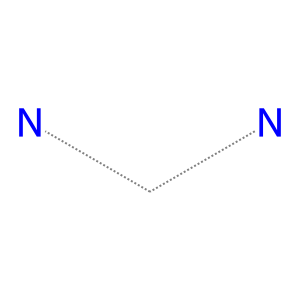

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw

# Define the SMARTS pattern: Nitrogen - Carbon - Nitrogen
smarts = "[N]~[C]~[N]"

# Convert to Mol object
mol = Chem.MolFromSmarts(smarts)


# Draw the pattern
Draw.MolToImage(mol, size=(300, 300))
